# Logistic Regression for non linear data

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons

feature_names = ["Feature #0", "Feature #1"]
target_name = "class"

X, y = make_moons(n_samples=100, noise=0.13, random_state=42)

# We store both the data and target in a dataframe to ease plotting
moons = pd.DataFrame(
    np.concatenate([X, y[:, np.newaxis]], axis=1),
    columns=feature_names + [target_name],
)
data_moons, target_moons = moons[feature_names], moons[target_name]

In [3]:
data_moons.head()

,Feature #0,Feature #1
0,1.601112,-0.473016
1,0.080326,0.478317
2,0.742979,-0.381052
3,-1.083818,0.239096
4,-0.758093,0.169001


In [5]:
target_moons.head()

0    1.0
1    1.0
2    1.0
3    0.0
4    0.0
Name: class, dtype: float64

In [6]:
from sklearn.datasets import make_gaussian_quantiles

X, y = make_gaussian_quantiles(
    n_samples=100, n_features=2, n_classes=2, random_state=42
)
gauss = pd.DataFrame(
    np.concatenate([X, y[:, np.newaxis]], axis=1),
    columns=feature_names + [target_name],
)
data_gauss, target_gauss = gauss[feature_names], gauss[target_name]

In [7]:
xor = pd.DataFrame(
    np.random.RandomState(0).uniform(low=-1, high=1, size=(200, 2)),
    columns=feature_names,
)
target_xor = np.logical_xor(xor["Feature #0"] > 0, xor["Feature #1"] > 0)
target_xor = target_xor.astype(np.int32)
xor["class"] = target_xor
data_xor = xor[feature_names]

[Text(0.5, 1.0, 'The XOR dataset'), Text(0.5, 0, 'Feature #0')]

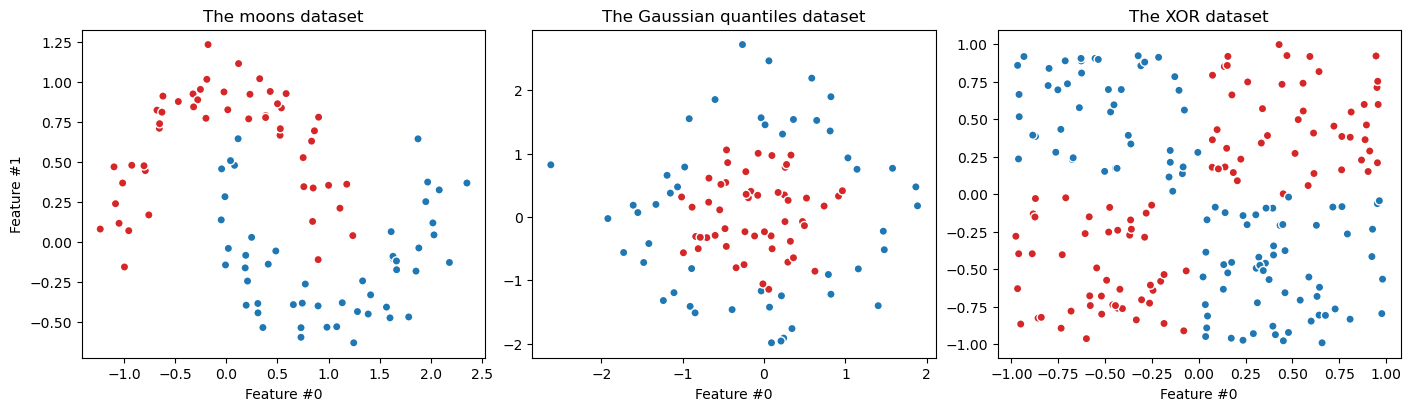

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


_, axs = plt.subplots(ncols=3, figsize=(14, 4), constrained_layout=True)

common_scatter_plot_params = dict(
    cmap=ListedColormap(["tab:red", "tab:blue"]),
    edgecolor="white",
    linewidth=1,
)

axs[0].scatter(
    data_moons[feature_names[0]],
    data_moons[feature_names[1]],
    c=target_moons,
    **common_scatter_plot_params,
)
axs[1].scatter(
    data_gauss[feature_names[0]],
    data_gauss[feature_names[1]],
    c=target_gauss,
    **common_scatter_plot_params,
)
axs[2].scatter(
    data_xor[feature_names[0]],
    data_xor[feature_names[1]],
    c=target_xor,
    **common_scatter_plot_params,
)
axs[0].set(
    title="The moons dataset",
    xlabel=feature_names[0],
    ylabel=feature_names[1],
)
axs[1].set(
    title="The Gaussian quantiles dataset",
    xlabel=feature_names[0],
)
axs[2].set(
    title="The XOR dataset",
    xlabel=feature_names[0],
)

In [10]:
from sklearn.inspection import DecisionBoundaryDisplay


def plot_decision_boundary(model, title=None):
    datasets = [
        (data_moons, target_moons),
        (data_gauss, target_gauss),
        (data_xor, target_xor),
    ]
    fig, axs = plt.subplots(
        ncols=3,
        figsize=(14, 4),
        constrained_layout=True,
    )

    for i, ax, (data, target) in zip(
        range(len(datasets)),
        axs,
        datasets,
    ):
        model.fit(data, target)
        DecisionBoundaryDisplay.from_estimator(
            model,
            data,
            response_method="predict_proba",
            plot_method="pcolormesh",
            cmap="RdBu",
            alpha=0.8,
            # Setting vmin and vmax to the extreme values of the probability to
            # ensure that 0.5 is mapped to white (the middle) of the blue-red
            # colormap.
            vmin=0,
            vmax=1,
            ax=ax,
        )
        DecisionBoundaryDisplay.from_estimator(
            model,
            data,
            response_method="predict_proba",
            plot_method="contour",
            alpha=0.8,
            levels=[0.5],  # 0.5 probability contour line
            linestyles="--",
            linewidths=2,
            ax=ax,
        )
        ax.scatter(
            data[feature_names[0]],
            data[feature_names[1]],
            c=target,
            **common_scatter_plot_params,
        )
        if i > 0:
            ax.set_ylabel(None)
    if title is not None:
        fig.suptitle(title)

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_regression = make_pipeline(StandardScaler(), LogisticRegression())
logistic_regression

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

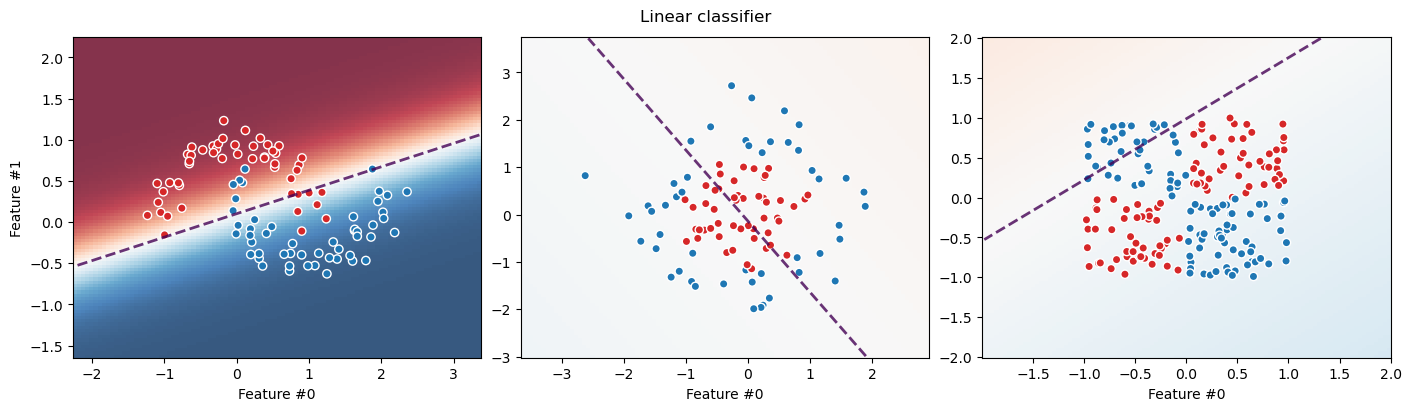

In [12]:
plot_decision_boundary(logistic_regression, title="Linear classifier")

In [14]:
from sklearn.preprocessing import KBinsDiscretizer

classifier = make_pipeline(
    KBinsDiscretizer(n_bins=5, encode="onehot"),  # already the default params
    LogisticRegression(),
)
classifier

Pipeline(steps=[('kbinsdiscretizer', KBinsDiscretizer()),
                ('logisticregression', LogisticRegression())])

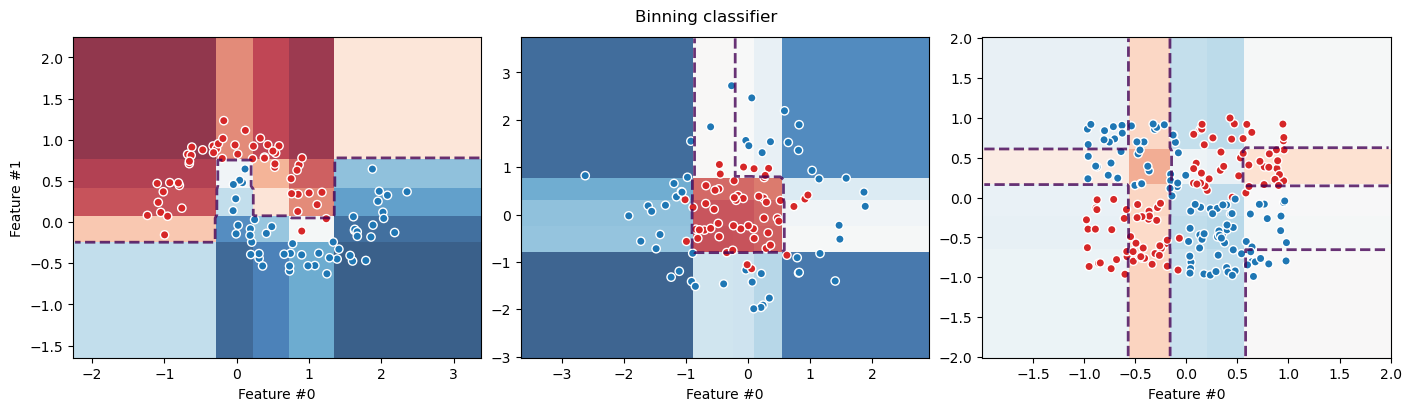

In [15]:
plot_decision_boundary(classifier, title="Binning classifier")

In [16]:
from sklearn.preprocessing import SplineTransformer

classifier = make_pipeline(
    SplineTransformer(degree=3, n_knots=5),
    LogisticRegression(),
)
classifier

Pipeline(steps=[('splinetransformer', SplineTransformer()),
                ('logisticregression', LogisticRegression())])

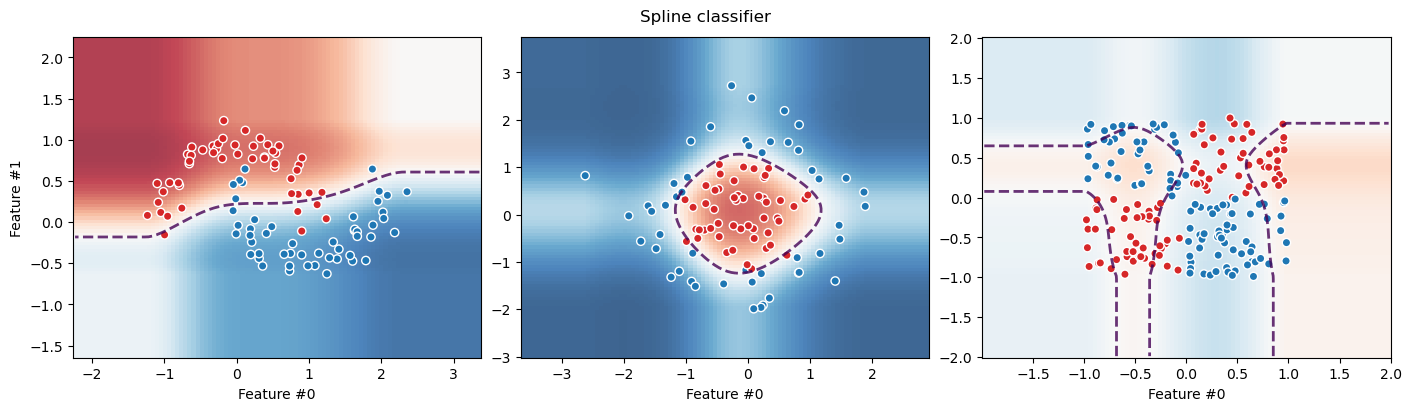

In [17]:
plot_decision_boundary(classifier, title="Spline classifier")

In [22]:
from sklearn.preprocessing import PolynomialFeatures

classifier = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=3, include_bias=False),
    LogisticRegression(C=10),
)
classifier

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('polynomialfeatures',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('logisticregression', LogisticRegression(C=10))])

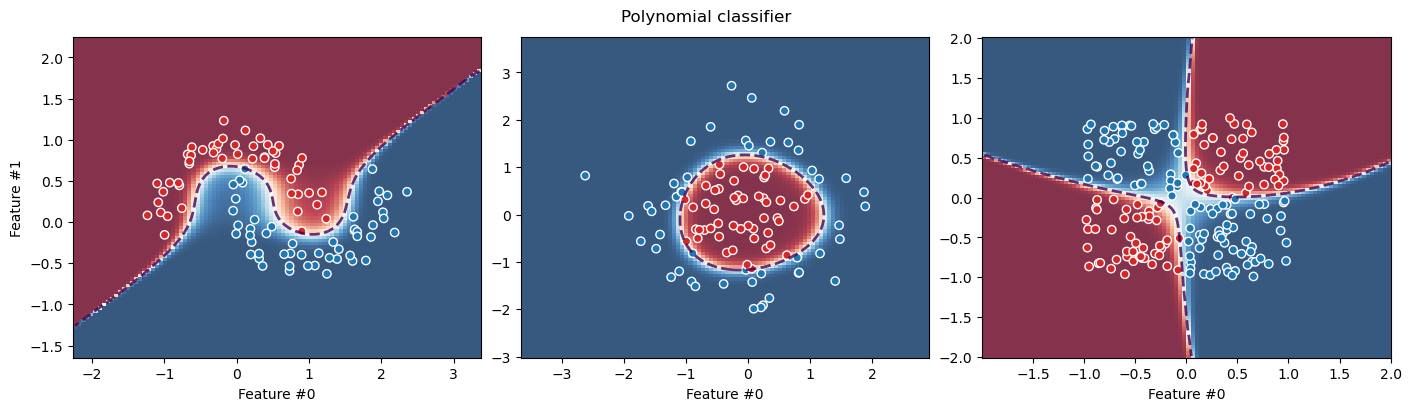

In [23]:
plot_decision_boundary(classifier, title="Polynomial classifier")

In [24]:
from sklearn.kernel_approximation import Nystroem

classifier = make_pipeline(
    StandardScaler(),
    Nystroem(kernel="poly", degree=3, coef0=1, n_components=100),
    LogisticRegression(C=10),
)
classifier

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('nystroem', Nystroem(coef0=1, degree=3, kernel='poly')),
                ('logisticregression', LogisticRegression(C=10))])

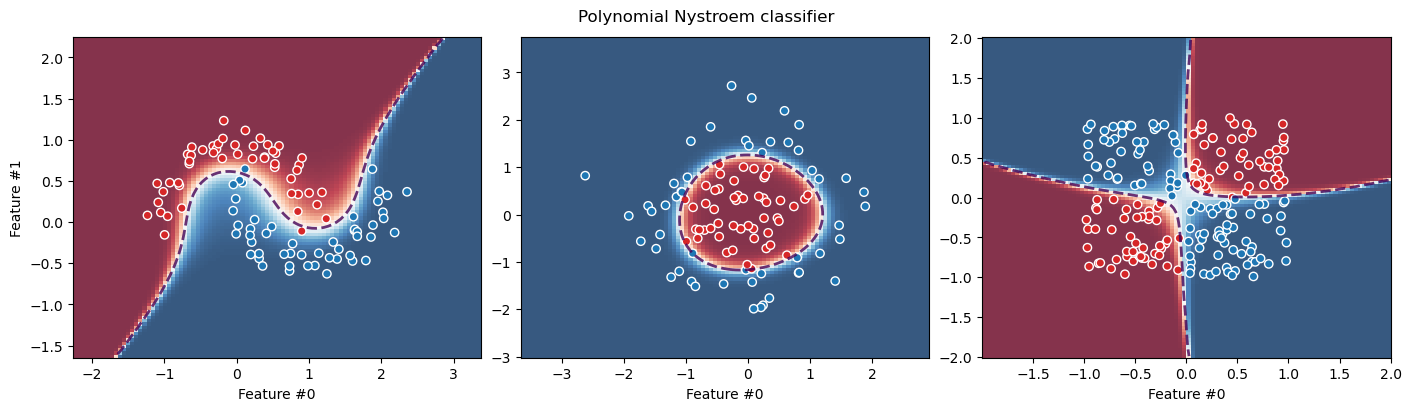

In [25]:
plot_decision_boundary(classifier, title="Polynomial Nystroem classifier")

In [26]:
from sklearn.kernel_approximation import Nystroem

classifier = make_pipeline(
    StandardScaler(),
    Nystroem(kernel="rbf", gamma=1, n_components=100),
    LogisticRegression(C=5),
)
classifier

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('nystroem', Nystroem(gamma=1)),
                ('logisticregression', LogisticRegression(C=5))])

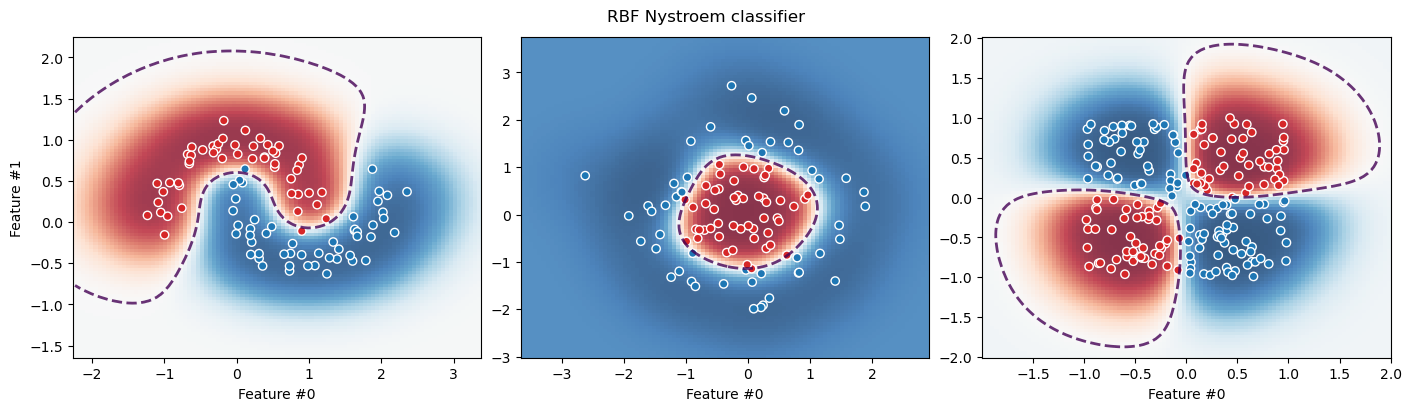

In [27]:
plot_decision_boundary(classifier, title="RBF Nystroem classifier")

In [28]:
classifier = make_pipeline(
    KBinsDiscretizer(n_bins=5),
    Nystroem(kernel="rbf", gamma=1.0, n_components=100),
    LogisticRegression(),
)
classifier

Pipeline(steps=[('kbinsdiscretizer', KBinsDiscretizer()),
                ('nystroem', Nystroem(gamma=1.0)),
                ('logisticregression', LogisticRegression())])

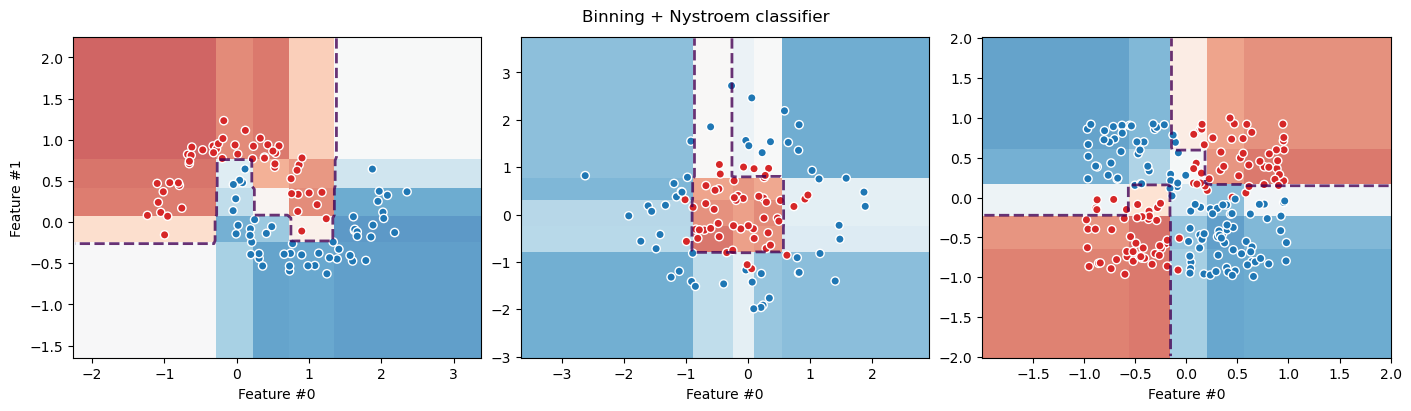

In [29]:
plot_decision_boundary(classifier, title="Binning + Nystroem classifier")

In [30]:
from sklearn.kernel_approximation import Nystroem

classifier = make_pipeline(
    SplineTransformer(n_knots=5),
    Nystroem(kernel="rbf", gamma=1.0, n_components=100),
    LogisticRegression(),
)
classifier

Pipeline(steps=[('splinetransformer', SplineTransformer()),
                ('nystroem', Nystroem(gamma=1.0)),
                ('logisticregression', LogisticRegression())])

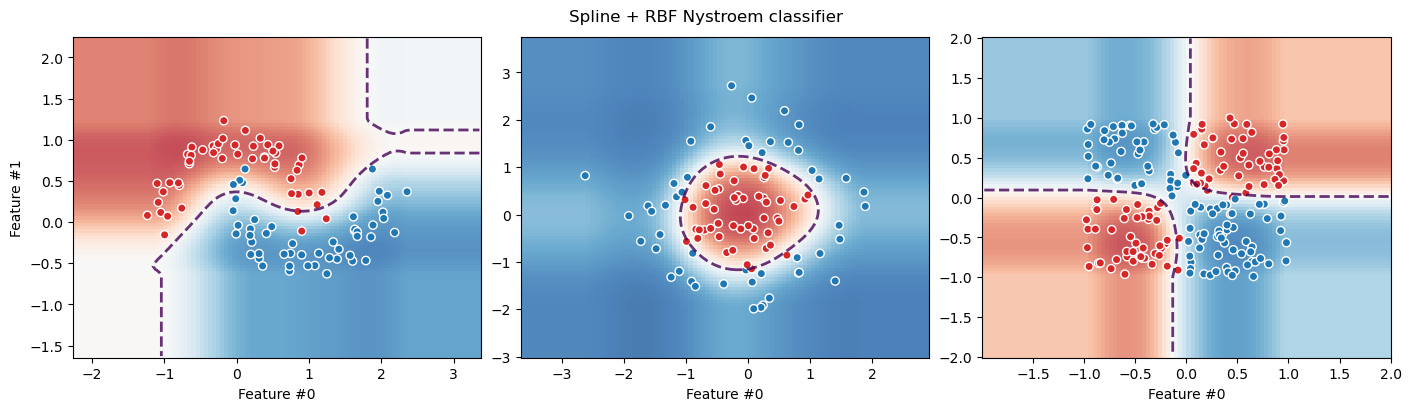

In [31]:
plot_decision_boundary(classifier, title="Spline + RBF Nystroem classifier")

- Linear models such as logistic regression can be used for classification on non-linearly separable datasets by leveraging non-linear feature engineering.
- Transformers such as KBinsDiscretizer and SplineTransformer can be used to engineer non-linear features independently for each original feature.
- As a result, these transformers cannot capture interactions between the orignal features (and then would fail on the XOR classification task).
- Despite this limitation they already augment the expressivity of the pipeline, which can be sufficient for some datasets.
- They also favor axis-aligned decision boundaries, in particular in the low density regions of the feature space (axis-aligned extrapolation).
- Transformers such as PolynomialFeatures and Nystroem can be used to engineer non-linear features that capture interactions between the original features.
- It can be useful to combine several feature engineering transformers in a single pipeline to build a more expressive model, for instance to favor axis-aligned extrapolation while also capturing interactions.
- In particular, if the original dataset has both numerical and categorical features, it can be useful to apply binning or a spline transformation to the numerical features and one-hot encoding to the categorical features. Then, the resulting features can be combined with a kernel approximation to model interactions between numerical and categorical features. This can be achieved with the help of ColumnTransformer.